# **Problem Statement**

**Principle Component Analysis**

Write codes in Python to perform PCA and understand why we need such unsupervised learning method. Please implement PCA as it has been done in the Nature Primer. See here. You will ALMOST (the data point values may differ a bit, but the patterns will be similar) be reproducing Figure 1 of the paper. The data for all 105 patient samples are organized in three files.

    data/class.tsv: has the labels. 1 (ER+ breast cancer), 0 (ER- breast cancer).

    data/filtered.tsv.gz: complete dataset. Header is the ID for genes.

    data/columns.tsv.gz: ID to gene name mapping.

For example, 4404 is the ID for gene XBP1 (Figure 1a - Y-axis).

Your goal is to:

Extract XBP1 and GATA3 expression levels in all 105 patients, and generate the scatter plot as seen in 1a (coloring should be done by the class). Remember that pattern in your plot should be similar to the paper.

Run PCA on the matrix and project these 2-D points on PC1. Generate Fgure 1c.

See the plot below.

## Gene Expression Analysis and PCA on Breast Cancer Data

### Objective:

To analyze the expression of two genes, **GATA3** and **XBP1**, in 105 breast cancer patient samples and explore how these genes help distinguish between **ER+ (estrogen receptor-positive)** and **ER− (estrogen receptor-negative)** subtypes. This analysis includes:

- Visualizing raw gene expression data (Figure 1a),
- Applying **Principal Component Analysis (PCA)** to identify dominant expression patterns (Figures 1b and 1c).

### Part 1: Visualizing Raw Gene Expression (Figure 1a)

1. Data Loading:

   - Load the full gene expression matrix from `filtered.tsv.gz`, where each row is a patient sample and each column corresponds to a gene (represented by an ID).
   - Use `columns.tsv.gz` to map gene IDs to gene names and locate the specific columns for **GATA3** and **XBP1**.
   - Load `class.tsv` to extract ER status labels (`0` for ER− and `1` for ER+).

2. Scatter Plot Generation:

   - Extract GATA3 and XBP1 expression values across all patients.
   - Create a 2D scatter plot with:
     - X-axis: GATA3 expression,
     - Y-axis: XBP1 expression.
     - Color code:
       - Red for ER+ samples,
       - Black for ER− samples.

3. Interpretation:

   - This plot provides an initial visual assessment of whether these two genes show differential expression patterns across ER status.
   - ER+ samples tend to show higher GATA3 expression, though a complete separation between classes is not evident at this stage.

### Part 2: Applying PCA and Projecting onto Principal Components (Figures 1b, 1c)

1. Purpose of PCA:

   - PCA is an unsupervised learning method that identifies directions (principal components) in which the data shows the most variance, without using class labels.
   - It helps reduce dimensionality while preserving meaningful patterns in the data.

2. Why an Unsupervised Learning Method is Needed:

   - In biological data, class labels such as ER status may not always be available or reliable.
   - PCA helps uncover **natural structure** and **variation** in the data based only on gene expression, independent of labels.
   - It is useful for **exploratory analysis**, especially when we are interested in discovering new patterns or validating whether known classifications (like ER+ and ER−) align with inherent structure in the data.
   - PCA also helps in **noise reduction** by focusing on components that explain the most variance, making downstream interpretation clearer.

3. Performing PCA:

   - Run PCA on the 2D matrix consisting of GATA3 and XBP1 expression values.
   - Extract the top two components:
     - PC1: the direction capturing the most variance,
     - PC2: orthogonal to PC1.

4. Visualizing PCA Axes (Figure 1b):

   - Overlay the PC1 and PC2 vectors on the original scatter plot to illustrate how PCA reorients the data.
   - If needed, reverse PC1’s direction so that ER+ samples project more positively along the axis, consistent with the original figure in the reference paper.

5. Projection onto PC1 (Figure 1c):

   - Project each data point onto the PC1 axis, reducing the 2D data to a single dimension.
   - Plot the projections in three separate 1D scatter plots:
     - All samples,
     - ER− samples only,
     - ER+ samples only.

6. Biological Insight:

   - This 1D projection highlights clearer class separation than the raw expression plot, revealing that PCA has effectively captured biologically meaningful variation between ER+ and ER− cases.

7. Explained Variance:

   - Report the proportion of total variance explained by PC1.
   - A high explained variance confirms the usefulness of PCA for this gene pair in distinguishing breast cancer subtypes.


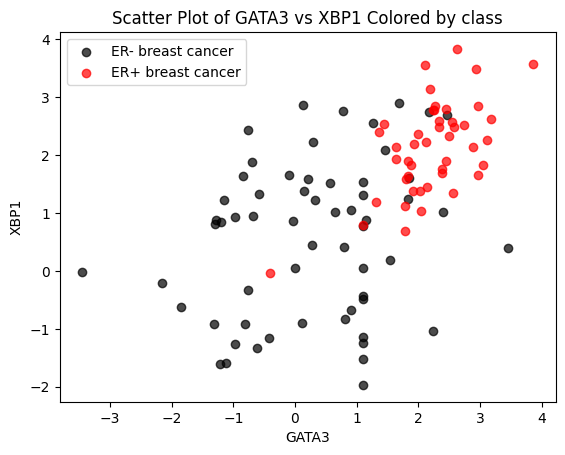

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("filtered.tsv", sep="\t")
df1 = pd.read_csv("class.tsv", sep="\t", header=None)
df2 = pd.read_csv("columns.tsv", sep="\t", comment="#")

# Extract the IDs corresponding to the 'GATA3' and 'XBP1' gene symbols from the columns dataframe
x1 = (df2.loc[df2['GeneSymbol'] == 'GATA3', 'ID'].values[0])
y1 = df2.loc[df2['GeneSymbol'] == 'XBP1', 'ID'].values[0]

# Convert the IDs to strings for compatibility with the main dataframe
x1 = " " + str(x1)
y1 = " " + str(y1)
X = df[x1].values
Y = df[y1].values
Z = df1[0].values

mask0 = (Z == 0)
mask1 = (Z == 1)

plt.scatter(X[mask0], Y[mask0], color='black', alpha=0.7, label='ER- breast cancer')
plt.scatter(X[mask1], Y[mask1], color='red', alpha=0.7, label='ER+ breast cancer')

plt.xlabel("GATA3")
plt.ylabel("XBP1")
plt.title("Scatter Plot of GATA3 vs XBP1 Colored by class")
plt.legend()

plt.show()


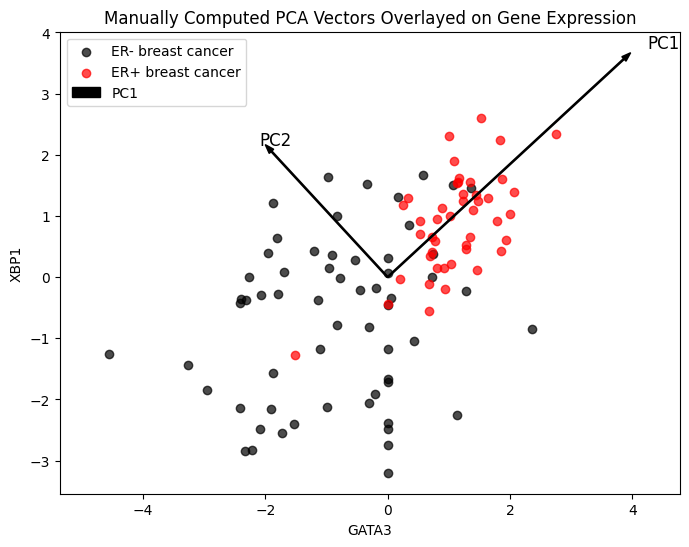

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

X_vals = X
Y_vals = Y
Z_vals = Z

data = np.vstack((X_vals, Y_vals)).T
mean = np.mean(data, axis=0)
data_centered = data - mean

cov_matrix = np.cov(data_centered.T)
eig_vals, eig_vecs = np.linalg.eig(cov_matrix)

sorted_indices = np.argsort(eig_vals)[::-1]
eig_vals = eig_vals[sorted_indices]
eig_vecs = eig_vecs[:, sorted_indices]

components = eig_vecs.T
explained = eig_vals

mask0 = (Z_vals == 0)
mask1 = (Z_vals == 1)

plt.figure(figsize=(8, 6))
plt.scatter(data_centered[mask0, 0], data_centered[mask0, 1], color='black', alpha=0.7, label='ER- breast cancer')
plt.scatter(data_centered[mask1, 0], data_centered[mask1, 1], color='red', alpha=0.7, label='ER+ breast cancer')

for i in range(2):
    plt.arrow(0, 0, components[i, 0] * np.sqrt(explained[i]) * 3, components[i, 1] * np.sqrt(explained[i]) * 3,
              color='black', width=0.02, head_width=0.1, label=f'PC{i+1}' if i == 0 else None)
    plt.text(components[i, 0] * np.sqrt(explained[i]) * 3 * 1.1, components[i, 1] * np.sqrt(explained[i]) * 3 * 1.05,
             f'PC{i+1}', color='black', fontsize=12)

plt.xlabel("GATA3")
plt.ylabel("XBP1")
plt.title("Manually Computed PCA Vectors Overlayed on Gene Expression")
plt.legend()

plt.axis('equal')
plt.show()


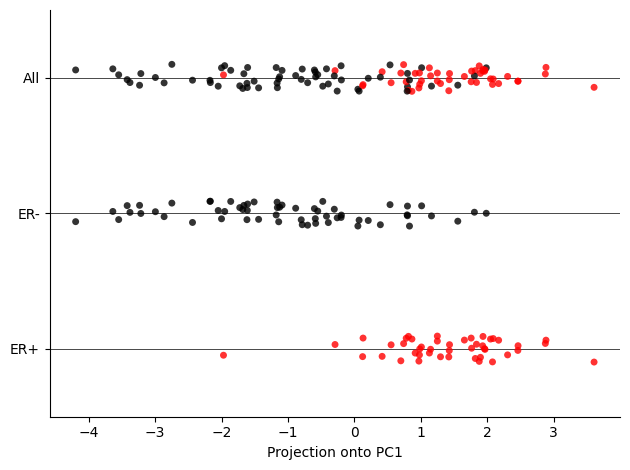

In [ ]:
import pandas as pd
import seaborn as sns

pc1_vector = eig_vecs[:, 0]
pc1_projection = data_centered @ pc1_vector

df_all = pd.DataFrame({
    "PC1": pc1_projection,
    "Group": "All",
    "Color": np.where(Z == 0, "black", "red")
})

df_er_minus = pd.DataFrame({
    "PC1": pc1_projection[Z == 0],
    "Group": "ER-",
    "Color": "black"
})

df_er_plus = pd.DataFrame({
    "PC1": pc1_projection[Z == 1],
    "Group": "ER+",
    "Color": "red"
})

plot_df = pd.concat([df_all, df_er_minus, df_er_plus], ignore_index=True)

ax = sns.stripplot(data=plot_df, x="PC1", y="Group", hue="Color",
                   palette={"black": "black", "red": "red"},
                   dodge=False, jitter=True, alpha=0.8, size=5)

ax.yaxis.grid(True, linestyle='-', color='black', linewidth=0.5, alpha=1.0)

plt.xlabel("Projection onto PC1")
plt.ylabel("")
plt.legend([], [], frameon=False)
sns.despine()
plt.tight_layout()

plt.show()
